In [52]:
import sys
sys.path.append("../../../src/rice_ml")

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from rice_ml.unsupervised_learning.k_means_clustering import (
    load_census_data,
    clean_census_data,
    encode_features,
    scale_features,
    compute_elbow_inertia,
    fit_kmeans,
    run_pca,
    attach_clusters,
    summarize_clusters
)


In [54]:
df = load_census_data("../../../datasets/census_income.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [55]:
numeric_cols = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
categorical_cols = ["workclass","education","marital_status","occupation","relationship","race","sex","native_country"]

selected_columns = numeric_cols + ["income"] + categorical_cols


In [56]:
df = clean_census_data(df, selected_columns)
y_income = df["income"].map({"<=50K": 0, ">50K": 1}).values
df_features = df.drop(columns=["income"])

In [64]:
df_encoded = encode_features(df_features, categorical_cols, drop_first=True)
for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors="coerce")

df_encoded = df_encoded.dropna().reset_index(drop=True)
X_scaled, scaler = scale_features(df_encoded)

X_scaled.shape

(45222, 96)

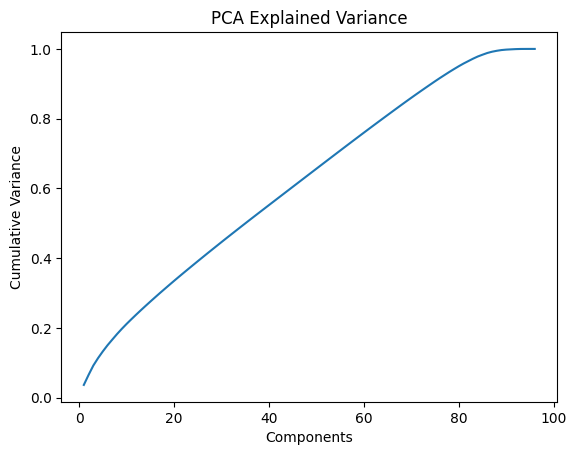

2 PC variance: 0.06534097377066708


In [58]:
pca_temp = PCA()
X_pca_temp = pca_temp.fit_transform(X_scaled)

explained = pca_temp.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.plot(range(1, len(cumulative)+1), cumulative)
plt.title("PCA Explained Variance")
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()

print("2 PC variance:", cumulative[1])

In [59]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(np.cumsum(pca.explained_variance_ratio_)[:10])


[0.03667989 0.06534097 0.09220055 0.11358531 0.13277777 0.15055587
 0.16665141 0.1825396  0.19736602 0.2114241 ]


In [60]:
elbow_results = compute_elbow_inertia(X_scaled, range(1, 9))


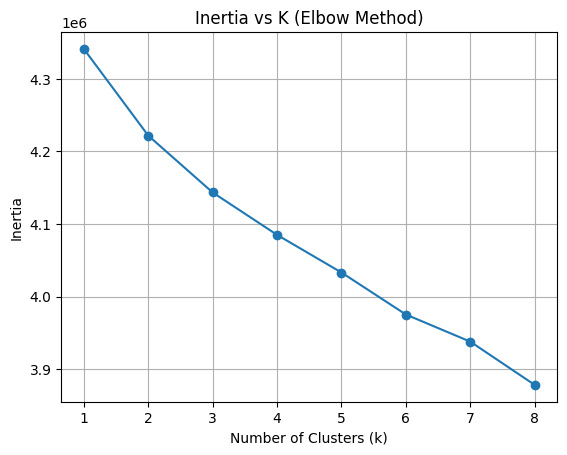

In [61]:
inertia_vals = []
k_values = range(1, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_vals.append(km.inertia_)

plt.plot(k_values, inertia_vals, marker="o")
plt.title("Inertia vs K (Elbow Method)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [69]:
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_

print("Cluster counts:", np.bincount(labels))

df_clusters = df.copy()
df_clusters["cluster"] = labels


Cluster counts: [ 7213 19202 18807]


In [70]:
# Only keep columns that are actually numeric + cluster
valid_numeric_cols = df_clusters.select_dtypes(include=[np.number]).columns.tolist()

# Print this to confirm what you are clustering
print("Using these numeric columns for cluster summary:", valid_numeric_cols)

# Now compute means (THIS WILL WORK because it's only numbers)
print(df_clusters.groupby("cluster")[valid_numeric_cols].mean())

Using these numeric columns for cluster summary: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'cluster']
               age         fnlwgt  education_num  capital_gain  capital_loss  \
cluster                                                                        
0        37.237904  222840.154721       9.137945    642.346874     60.852904   
1        43.345797  181304.660712      10.519061   1990.002656    126.812988   
2        34.151752  185645.027064      10.085500    370.266603     60.215186   

         hours_per_week  cluster  
cluster                           
0             39.219326      0.0  
1             44.375325      1.0  
2             38.087680      2.0  


In [72]:
print("\nIncome influence per cluster:")
df_clusters.groupby("cluster")[valid_numeric_cols].mean()
summarize_clusters(df_clusters, "cluster", valid_numeric_cols) 


Income influence per cluster:


age                       fnlwgt                   \
              mean median  count           mean    median  count   
cluster                                                            
0        37.237904   36.0   7213  222840.154721  202420.0   7213   
1        43.345797   42.0  19202  181304.660712  173468.5  19202   
2        34.151752   31.0  18807  185645.027064  177287.0  18807   

        education_num               capital_gain  ...        capital_loss  \
                 mean median  count         mean  ...  count         mean   
cluster                                           ...                       
0            9.137945    9.0   7213   642.346874  ...   7213    60.852904   
1           10.519061   10.0  19202  1990.002656  ...  19202   126.812988   
2           10.085500   10.0  18807   370.266603  ...  18807    60.215186   

                      hours_per_week               cluster                
        median  count           mean median  count    mean median  count  
cluster                                                                   
0          0.0   7213      39.219326   40.0   7213     0.0    0.0   7213  
1          0.0  19202      44.375325   40.0  19202     1.0    1.0  19202  
2          0.0  18807      38.087680   40.0  18807     2.0    2.0  18807  

[3 rows x 21 columns]

In [78]:
df_clusters["income"] = df_clusters["income"].astype("category").cat.codes
df_clusters.groupby("cluster")["income"].mean().round(3)




cluster
0    0.136
1    0.468
2    0.066
Name: income, dtype: float64

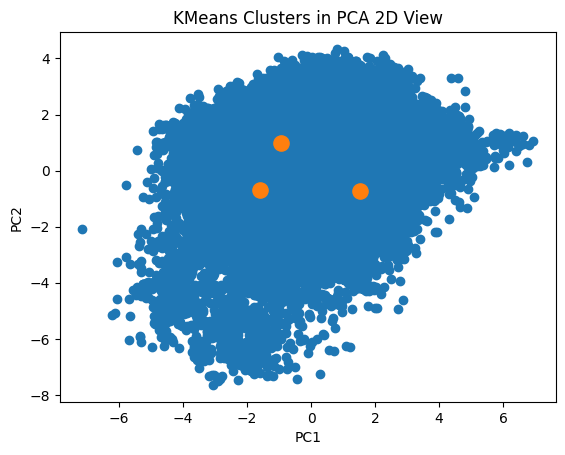

In [75]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1])
centroids_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=120)
plt.title("KMeans Clusters in PCA 2D View")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [76]:
income_map = df_clusters.groupby("cluster")["income"].mean()
high_income_cluster = income_map.idxmax()

print("Income influence per cluster:\n", income_map.round(3))
print("\nMost high-income behavior cluster is:", high_income_cluster)


Income influence per cluster:
 cluster
0    0.136
1    0.468
2    0.066
Name: income, dtype: float64

Most high-income behavior cluster is: 1


In [83]:
def predict_income_cluster(sample_raw):
    # Scale input
    sample_scaled = scaler.transform(sample_raw.reshape(1, -1))

    # Get cluster assignment
    cluster = kmeans.predict(sample_scaled)[0]

    # Compute cluster income influence
    cluster_members = df_clusters[df_clusters["cluster"] == cluster]
    income_score = cluster_members["income"].mean()

    return {
        "prediction": ">50K" if income_score > 0.5 else "<=50K",
        "cluster": int(cluster),
        "income_score": round(float(income_score), 3)
    }

# Example test
print(predict_income_cluster(X_scaled[0]))  # works


{'prediction': '<=50K', 'cluster': 2, 'income_score': 0.066}


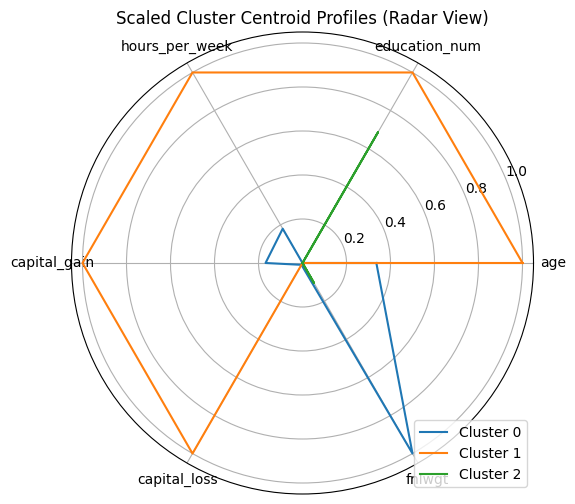

In [86]:
import math
# 1. Compute cluster centroids in original feature space
centroids = df_clusters.groupby("cluster")[["age","education_num","hours_per_week","capital_gain","capital_loss","fnlwgt"]].mean()

# 2. Scale centroids to 0–1 for radar visualization only
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
centroids_scaled = scaler.fit_transform(centroids)
centroids_scaled = pd.DataFrame(centroids_scaled, columns=centroids.columns, index=centroids.index)

# 3. Radar plot
categories = list(centroids.columns)
N = len(categories)

angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.figure(figsize=(6,6)), plt.subplot(polar=True)

for i, row in centroids_scaled.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=f"Cluster {i}")

plt.xticks(angles[:-1], categories)
ax.set_title("Scaled Cluster Centroid Profiles (Radar View)")
plt.legend()
plt.show()


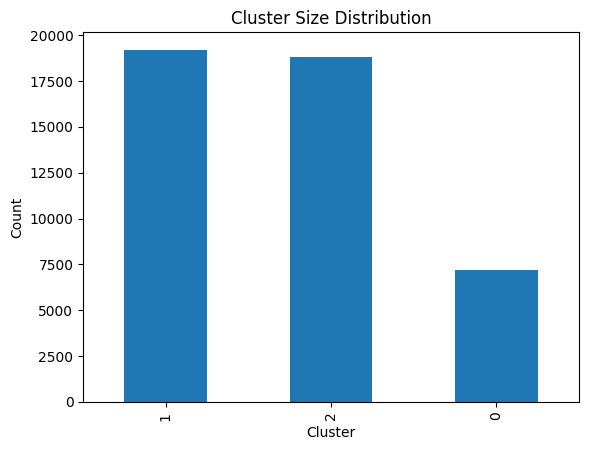

In [87]:
df_clusters["cluster"].value_counts().plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()
